# Prepare the 2019 and 2026 glacier outlines

This notebook prepares Sentinel-1 inputs and derives constrained glacier
outlines for Heard Island in 2019 and 2026. These extend the existing
1947, 1988 and 2014 outline series used in the project.

The analysis focuses on Brown and Stephenson glaciers. Island-wide outputs
provide spatial context, but known mapping issues elsewhere limit their
use for quantitative analysis.

The workflow uses matched Sentinel-1A IW HH acquisitions from ascending
relative orbit 100, 12-day interferometric coherence, the 2014 glacier
inventory, coastline and lagoon polygons, and an elevation model.

Raw downloads are stored in `Input_Data/raw/`. Processed rasters and vector
outputs are stored in `Output_Data/processed/`. The accepted outlines are
stored in `Output_Data/processed/glacier_outlines_final/`.

Acquisition cells are optional and are disabled by default using
`run_downloads = False`. Normal runs reuse the downloaded inputs.

In [1]:
## Install the image segmentation package ##

# %pip install scikit-image

In [53]:
## Import the required packages ##

from datetime import datetime, timezone
from getpass import getpass
from math import ceil, floor
from pathlib import Path
from tempfile import TemporaryDirectory
import json
import os
import shutil
import sys
import zipfile

# Use the GDAL support files supplied by the Windows conda environment.
gdal_data = Path(sys.prefix) / "Library" / "share" / "gdal"

if (gdal_data / "gdalvrt.xsd").exists():
    os.environ["GDAL_DATA"] = str(gdal_data)

import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MaxNLocator
import numpy as np
import rasterio
import requests

from pystac_client import Client
from rasterio.enums import Resampling
from rasterio.features import rasterize, shapes
from rasterio.merge import merge
from rasterio.vrt import WarpedVRT
from rasterio.warp import transform_bounds, transform_geom

from scipy import ndimage as ndi
from shapely.geometry import box, shape as shapely_shape
from shapely.ops import unary_union
from skimage.filters import sobel
from skimage.segmentation import watershed

In [55]:
## Set project directories and file paths ##

# Run the notebook from the project folder containing Input_Data.
project_dir = Path.cwd()
input_dir = project_dir / "Input_Data"
raw_dir = input_dir / "raw"
processed_dir = project_dir / "Output_Data" / "processed"
coherence_dir = raw_dir / "coherence"

# Existing data are reused during normal notebook runs.
run_downloads = False

scene_dates = {
    2019: "2019-04-13",
    2026: "2026-04-12"}

radar_paths = {
    year: processed_dir / f"S1A_IW_HH_{date}_RTC_10m.tif"
    for year, date in scene_dates.items()}

coherence_paths = {
    year: coherence_dir / f"Heard_coherence_{year}.tif"
    for year in scene_dates}

glacier_path = input_dir / "heard_island_shp" / "Glacier_2014.shp"
coast_path = input_dir / "HIMI_Features" / "himi_coastline_py.gpkg"
lagoon_path = input_dir / "heard_island_shp" / "UpdatedHI_Lagoons2014.shp"
orders_path = processed_dir / "coherence_orders.json"

output_dir = processed_dir / "coherence_watershed_v5_1000m_lock"
locked_dir = processed_dir / "coherence_watershed_v6_1000m_lock"
final_dir = processed_dir / "glacier_outlines_final"

if not input_dir.is_dir() or not processed_dir.is_dir():
    raise FileNotFoundError(
        "Run from the project root after moving raw into Input_Data "
        "and processed into Output_Data.")

In [56]:
## Apply the book style to methodology figures ##

from matplotlib.ticker import FuncFormatter, MaxNLocator

book_plot_style = json.loads(
    (processed_dir / "book_figure_style.json").read_text(
        encoding = "utf-8"))

figure_dir = project_dir / "Figures"
figure_dir.mkdir(parents = True, exist_ok = True)


def save_methodology_figure(figure, map_axes, filename):
    # Display projected metre coordinates as kilometres.
    for ax in np.asarray(map_axes).ravel():
        ax.xaxis.set_major_locator(MaxNLocator(nbins = 4))
        ax.yaxis.set_major_locator(MaxNLocator(nbins = 4))

        ax.xaxis.set_major_formatter(
            FuncFormatter(lambda value, position: f"{value / 1_000:g}"))

        ax.yaxis.set_major_formatter(
            FuncFormatter(lambda value, position: f"{value / 1_000:g}"))

        ax.set_xlabel("Easting (km)")
        ax.set_ylabel("Northing (km)")
        ax.set_aspect("equal")
        ax.tick_params(labelsize = 10)

    # Save the book image and a vector version with editable text.
    for extension in ("png", "svg"):
        figure.savefig(
            figure_dir / f"{filename}.{extension}",
            dpi = 300, bbox_inches = "tight")

In [4]:
## Set the matched full-island SAR grid

# Include a margin around the AAD Heard Island map extent.
full_aoi_wgs84 = (73.18, -53.22, 73.99, -52.91)
pixel_size = 10
maximum_tile_pixels = 2400

min_x, min_y, max_x, max_y = transform_bounds(
    "EPSG:4326",
    "EPSG:32743",
    *full_aoi_wgs84,
    densify_pts = 21)

min_x = floor(min_x / pixel_size) * pixel_size
min_y = floor(min_y / pixel_size) * pixel_size
max_x = ceil(max_x / pixel_size) * pixel_size
max_y = ceil(max_y / pixel_size) * pixel_size

full_width = int((max_x - min_x) / pixel_size)
full_height = int((max_y - min_y) / pixel_size)

tile_count = (
    ceil(full_width / maximum_tile_pixels)
    * ceil(full_height / maximum_tile_pixels))

print("Scenes:", scene_dates)
print(f"Full-island grid: {full_width} × {full_height} pixels")
print(f"Tiles per scene: {tile_count}")

Scenes: {2019: '2019-04-13', 2026: '2026-04-12'}
Full-island grid: 5496 × 3557 pixels
Tiles per scene: 6


In [5]:
## Download full-island 2019 IW tiles
if run_downloads:
    scene_date = scene_dates[2019]
    tile_dir = Path(tile_dir = processed_dir / "sar_2019_iw_tiles")
    tile_dir.mkdir(parents = True, exist_ok = True)

    # Keep the same three bands as the Stripmap trial.
    evalscript = """
    //VERSION=3

    function setup() {
        return {
            input: ["HH", "shadowMask", "dataMask"],
            output: {
                id: "default",
                bands: 3,
                sampleType: "FLOAT32"
            }
        }
    }

    function evaluatePixel(sample) {
        let hhDb = sample.HH > 0
            ? 10 * Math.log(sample.HH) / Math.LN10
            : -99;

        return [hhDb, sample.shadowMask, sample.dataMask];
    }
    """

    def valid_tile(path, width, height):
        if not path.exists() or path.stat().st_size < 1024:
            return False

        try:
            with rasterio.open(path) as source:
                if (
                    source.width != width
                    or source.height != height
                    or source.count != 3
                    or source.crs.to_epsg() != 32743
                ):
                    return False

                source.read(1, window = ((0, 1), (0, 1)))
                return True
        except (rasterio.errors.RasterioIOError, OSError):
            return False

    # Prepare the six tile bounds on the shared 10 m grid.
    tile_specs = []

    for row_start in range(0, full_height, maximum_tile_pixels):
        for column_start in range(0, full_width, maximum_tile_pixels):
            tile_height = min(
                maximum_tile_pixels, full_height - row_start)
            tile_width = min(
                maximum_tile_pixels, full_width - column_start)

            tile_min_x = min_x + column_start * pixel_size
            tile_min_y = min_y + row_start * pixel_size

            tile_bounds = [
                tile_min_x,
                tile_min_y,
                tile_min_x + tile_width * pixel_size,
                tile_min_y + tile_height * pixel_size]

            tile_path = tile_dir / (
                f"S1A_IW_HH_{scene_date}_RTC_10m_"
                f"r{row_start}_c{column_start}.tif")

            tile_specs.append((
                tile_path, tile_width, tile_height, tile_bounds))

    missing_tiles = [
        spec for spec in tile_specs
        if not valid_tile(spec[0], spec[1], spec[2])]

    print(f"Valid tiles: {len(tile_specs) - len(missing_tiles)} of {len(tile_specs)}")
    print(f"Tiles to download: {len(missing_tiles)}")

    if missing_tiles:
        # Credentials are requested only when a download is needed.
        client_id = getpass("Copernicus client ID: ").strip()
        client_secret = getpass("Copernicus client secret: ").strip()

        if not client_id or not client_secret:
            raise ValueError("Both credentials are required")

        token_response = requests.post(
            "https://identity.dataspace.copernicus.eu/auth/"
            "realms/CDSE/protocol/openid-connect/token",
            data = {
                "grant_type": "client_credentials",
                "client_id": client_id,
                "client_secret": client_secret},
            timeout = 30)

        if not token_response.ok:
            raise RuntimeError(
                f"Authentication failed ({token_response.status_code}): "
                f"{token_response.text[:300]}")

        access_token = token_response.json()["access_token"]
        del client_secret

        for tile_path, tile_width, tile_height, tile_bounds in missing_tiles:
            request_body = {
                "input": {
                    "bounds": {
                        "bbox": tile_bounds,
                        "properties": {
                            "crs": (
                                "http://www.opengis.net/def/crs/"
                                "EPSG/0/32743")}},
                    "data": [{
                        "type": "sentinel-1-grd",
                        "dataFilter": {
                            "timeRange": {
                                "from": f"{scene_date}T14:19:00Z",
                                "to": f"{scene_date}T14:20:00Z"},
                            "acquisitionMode": "IW",
                            "polarization": "SH",
                            "orbitDirection": "ASCENDING",
                            "resolution": "HIGH"},
                        "processing": {
                            "backCoeff": "GAMMA0_TERRAIN",
                            "orthorectify": True,
                            "demInstance": "COPERNICUS_30",
                            "radiometricTerrainOversampling": 3,
                            "speckleFilter": {
                                "type": "LEE",
                                "windowSizeX": 5,
                                "windowSizeY": 5}}}]},
                "output": {
                    "width": tile_width,
                    "height": tile_height,
                    "responses": [{
                        "identifier": "default",
                        "format": {
                            "type": "image/tiff"}}]},
                "evalscript": evalscript}

            # Write to a temporary TIFF so an interrupted download
            # cannot masquerade as a completed tile.
            temporary_tile = tile_path.with_name(
                f"{tile_path.stem}_building.tif")
            temporary_tile.unlink(missing_ok = True)

            print("Downloading:", tile_path.name, flush = True)

            with requests.post(
                "https://sh.dataspace.copernicus.eu/process/v1",
                headers = {
                    "Authorization": f"Bearer {access_token}",
                    "Content-Type": "application/json",
                    "Accept": "image/tiff"},
                json = request_body,
                stream = True,
                timeout = (30, 300)) as response:

                if not response.ok:
                    raise RuntimeError(
                        f"Tile failed ({response.status_code}): "
                        f"{response.text[:500]}")

                with temporary_tile.open("wb") as output:
                    for chunk in response.iter_content(
                        chunk_size = 1024 * 1024
                    ):
                        if chunk:
                            output.write(chunk)

            if not valid_tile(
                temporary_tile, tile_width, tile_height
            ):
                raise RuntimeError(
                    f"Downloaded tile failed validation: {tile_path.name}")

            temporary_tile.replace(tile_path)
            print("Saved:", tile_path.name, flush = True)

    print("Valid final tiles:", sum(
        valid_tile(path, width, height)
        for path, width, height, _ in tile_specs))

In [6]:
## Mosaic the full-island 2019 IW tiles
if run_downloads:
    # Check the six inputs before writing a new mosaic.
    tile_paths = [spec[0] for spec in tile_specs]

    if not all(
        valid_tile(path, width, height)
        for path, width, height, _ in tile_specs
    ):
        raise RuntimeError("One or more 2019 IW tiles are missing or invalid")

    output_path = radar_paths[2019]
    temporary_output = output_path.with_name(
        f"{output_path.stem}_building.tif")

    # A previous interrupted mosaic may have left a damaged TIFF.
    temporary_output.unlink(missing_ok = True)

    print("Writing full-island mosaic in chunks...", flush = True)

    merge(
        tile_paths,
        dst_path = temporary_output,
        mem_limit = 64,
        dst_kwds = {
            "driver": "GTiff",
            "compress": "deflate",
            "predictor": 3,
            "tiled": True,
            "blockxsize": 256,
            "blockysize": 256,
            "BIGTIFF": "IF_SAFER"})

    with rasterio.open(temporary_output, "r+") as mosaic:
        mosaic_shape = (mosaic.count, mosaic.height, mosaic.width)

        if mosaic_shape != (3, full_height, full_width):
            raise RuntimeError(f"Unexpected mosaic shape: {shape}")

        mosaic.set_band_description(1, "HH backscatter (dB)")
        mosaic.set_band_description(2, "Radar shadow mask")
        mosaic.set_band_description(3, "Data mask")

    temporary_output.replace(output_path)

    print("Saved:", output_path)
    print("Shape:", shape)

In [7]:
## Download full-island 2026 IW tiles
if run_downloads:
    scene_date = scene_dates[2026]
    tile_dir = processed_dir / "sar_2026_iw_tiles"
    tile_dir.mkdir(parents = True, exist_ok = True)

    # Keep the same three bands as the Stripmap trial.
    evalscript = """
    //VERSION=3

    function setup() {
        return {
            input: ["HH", "shadowMask", "dataMask"],
            output: {
                id: "default",
                bands: 3,
                sampleType: "FLOAT32"
            }
        }
    }

    function evaluatePixel(sample) {
        let hhDb = sample.HH > 0
            ? 10 * Math.log(sample.HH) / Math.LN10
            : -99;

        return [hhDb, sample.shadowMask, sample.dataMask];
    }
    """

    def valid_tile(path, width, height):
        if not path.exists() or path.stat().st_size < 1024:
            return False

        try:
            with rasterio.open(path) as source:
                if (
                    source.width != width
                    or source.height != height
                    or source.count != 3
                    or source.crs.to_epsg() != 32743
                ):
                    return False

                source.read(1, window = ((0, 1), (0, 1)))
                return True
        except (rasterio.errors.RasterioIOError, OSError):
            return False

    # Prepare the six tile bounds on the shared 10 m grid.
    tile_specs = []

    for row_start in range(0, full_height, maximum_tile_pixels):
        for column_start in range(0, full_width, maximum_tile_pixels):
            tile_height = min(
                maximum_tile_pixels, full_height - row_start)
            tile_width = min(
                maximum_tile_pixels, full_width - column_start)

            tile_min_x = min_x + column_start * pixel_size
            tile_min_y = min_y + row_start * pixel_size

            tile_bounds = [
                tile_min_x,
                tile_min_y,
                tile_min_x + tile_width * pixel_size,
                tile_min_y + tile_height * pixel_size]

            tile_path = tile_dir / (
                f"S1A_IW_HH_{scene_date}_RTC_10m_"
                f"r{row_start}_c{column_start}.tif")

            tile_specs.append((
                tile_path, tile_width, tile_height, tile_bounds))

    missing_tiles = [
        spec for spec in tile_specs
        if not valid_tile(spec[0], spec[1], spec[2])]

    print(f"Valid tiles: {len(tile_specs) - len(missing_tiles)} of {len(tile_specs)}")
    print(f"Tiles to download: {len(missing_tiles)}")

    if missing_tiles:
        # Credentials are requested only when a download is needed.
        client_id = getpass("Copernicus client ID: ").strip()
        client_secret = getpass("Copernicus client secret: ").strip()

        if not client_id or not client_secret:
            raise ValueError("Both credentials are required")

        token_response = requests.post(
            "https://identity.dataspace.copernicus.eu/auth/"
            "realms/CDSE/protocol/openid-connect/token",
            data = {
                "grant_type": "client_credentials",
                "client_id": client_id,
                "client_secret": client_secret},
            timeout = 30)

        if not token_response.ok:
            raise RuntimeError(
                f"Authentication failed ({token_response.status_code}): "
                f"{token_response.text[:300]}")

        access_token = token_response.json()["access_token"]
        del client_secret

        for tile_path, tile_width, tile_height, tile_bounds in missing_tiles:
            request_body = {
                "input": {
                    "bounds": {
                        "bbox": tile_bounds,
                        "properties": {
                            "crs": (
                                "http://www.opengis.net/def/crs/"
                                "EPSG/0/32743")}},
                    "data": [{
                        "type": "sentinel-1-grd",
                        "dataFilter": {
                            "timeRange": {
                                "from": f"{scene_date}T14:19:00Z",
                                "to": f"{scene_date}T14:20:00Z"},
                            "acquisitionMode": "IW",
                            "polarization": "SH",
                            "orbitDirection": "ASCENDING",
                            "resolution": "HIGH"},
                        "processing": {
                            "backCoeff": "GAMMA0_TERRAIN",
                            "orthorectify": True,
                            "demInstance": "COPERNICUS_30",
                            "radiometricTerrainOversampling": 3,
                            "speckleFilter": {
                                "type": "LEE",
                                "windowSizeX": 5,
                                "windowSizeY": 5}}}]},
                "output": {
                    "width": tile_width,
                    "height": tile_height,
                    "responses": [{
                        "identifier": "default",
                        "format": {
                            "type": "image/tiff"}}]},
                "evalscript": evalscript}

            # Write to a temporary TIFF so an interrupted download
            # cannot masquerade as a completed tile.
            temporary_tile = tile_path.with_name(
                f"{tile_path.stem}_building.tif")
            temporary_tile.unlink(missing_ok = True)

            print("Downloading:", tile_path.name, flush = True)

            with requests.post(
                "https://sh.dataspace.copernicus.eu/process/v1",
                headers = {
                    "Authorization": f"Bearer {access_token}",
                    "Content-Type": "application/json",
                    "Accept": "image/tiff"},
                json = request_body,
                stream = True,
                timeout = (30, 300)) as response:

                if not response.ok:
                    raise RuntimeError(
                        f"Tile failed ({response.status_code}): "
                        f"{response.text[:500]}")

                with temporary_tile.open("wb") as output:
                    for chunk in response.iter_content(
                        chunk_size = 1024 * 1024
                    ):
                        if chunk:
                            output.write(chunk)

            if not valid_tile(
                temporary_tile, tile_width, tile_height
            ):
                raise RuntimeError(
                    f"Downloaded tile failed validation: {tile_path.name}")

            temporary_tile.replace(tile_path)
            print("Saved:", tile_path.name, flush = True)

    print("Valid final tiles:", sum(
        valid_tile(path, width, height)
        for path, width, height, _ in tile_specs))

In [8]:
## Mosaic the full-island 2026 IW tiles
if run_downloads:
    # Check the six inputs before writing a new mosaic.
    tile_paths = [spec[0] for spec in tile_specs]

    if not all(
        valid_tile(path, width, height)
        for path, width, height, _ in tile_specs
    ):
        raise RuntimeError("One or more 2026 IW tiles are missing or invalid")

    output_path = radar_paths[2026]
    temporary_output = output_path.with_name(
        f"{output_path.stem}_building.tif")

    # A previous interrupted mosaic may have left a damaged TIFF.
    temporary_output.unlink(missing_ok = True)

    print("Writing full-island mosaic in chunks...", flush = True)

    merge(
        tile_paths,
        dst_path = temporary_output,
        mem_limit = 64,
        dst_kwds = {
            "driver": "GTiff",
            "compress": "deflate",
            "predictor": 3,
            "tiled": True,
            "blockxsize": 256,
            "blockysize": 256,
            "BIGTIFF": "IF_SAFER"})

    with rasterio.open(temporary_output, "r+") as mosaic:
        mosaic_shape = (mosaic.count, mosaic.height, mosaic.width)

        if mosaic_shape != (3, full_height, full_width):
            raise RuntimeError(f"Unexpected mosaic shape: {mosaic_shape}")

        mosaic.set_band_description(1, "HH backscatter (dB)")
        mosaic.set_band_description(2, "Radar shadow mask")
        mosaic.set_band_description(3, "Data mask")

    temporary_output.replace(output_path)

    print("Saved:", output_path)
    print("Shape:", mosaic_shape)

## Deriving the glacier outlines: method and development decisions

### Imagery and initial difficulties

The first imagery trial used Sentinel-1 Stripmap data. This was replaced
by matched full-island Sentinel-1A IW HH acquisitions from ascending
relative orbit 100, dated 13 April 2019 and 12 April 2026.

The GRD backscatter requests used terrain-corrected gamma-nought,
orthorectification with the Copernicus 30 m DEM, and a 5 × 5 Lee speckle
filter. The downloaded tiles were mosaicked onto a shared 10 m grid in
WGS 84 / UTM zone 43S (EPSG:32743). Each mosaic contains HH backscatter
in decibels, a radar-shadow mask and a valid-data mask.

Visual inspection showed that HH brightness alone did not consistently
separate glacier ice from surrounding terrain. We therefore added
interferometric coherence as the main segmentation input. The GRD
mosaics supply the processing grid and observation masks; the final
segmentation does not classify HH brightness directly.

### Coherence acquisition

Coherence was obtained from matching SLC pairs spanning 1–13 April 2019
and 31 March–12 April 2026. Catalogue checks found 30 matching HH burst
positions within each pair, with their footprints jointly covering the
entire mosaic rectangle. Footprint coverage does not guarantee usable
radar observations at every pixel.

The older workflow name shown in the initial API example was unavailable
during development. We queried the available workflows and used
`card_cohinf`, requesting `CARD_COH` output with a 12-day interval,
`multilook = 1`, EPSG:32743 and 10 m output spacing.

The SLC pairs were processed by the Copernicus service. Individual bursts
were checked in the catalogue but were not downloaded and processed
locally. Order IDs and completed downloads were retained to avoid
unnecessary repeat submissions.

### Boundary delineation

The coherence rasters were aligned to the shared SAR grid using bilinear
resampling. Processing was restricted to mapped land, excluding the
updated 2014 lagoons. Outside the high-elevation override described
below, usable observations also required valid SAR coverage, no mapped
radar shadow, and finite coherence values within the expected range.

A normalised Gaussian filter, with a standard deviation of 30 m, reduced
local variation while accounting for invalid observations. A Sobel
gradient then highlighted spatial changes in the smoothed coherence.

Marker-controlled watershed segmentation used these gradients to
separate regions growing from candidate ice and stable-terrain seeds:

- Ice seeds had smoothed coherence ≤ 0.22 and lay at least 200 m inside
  the combined 2014 ice footprint.
- Stable-terrain seeds had smoothed coherence ≥ 0.45.
- Connected seed patches smaller than 1,000 m² were removed.
- Segmentation was limited to connected valid-data regions containing
  both seed classes.
- Four-neighbour connectivity was used.

These coherence thresholds select seed locations; they do not directly
define the final glacier boundary. The watershed uses the coherence
gradient to guide the separation between seeded regions.

Small preliminary ice components were removed before the elevation
override and vector clipping. The 1,000 m² filtering threshold therefore
does not guarantee that every final polygon fragment exceeds that area.

### Spatial and elevation constraints

Three constraints were applied following inspection of the candidates.

**Mapped lagoons were excluded.** The updated
`UpdatedHI_Lagoons2014.shp` polygons were removed from the land mask.
This reduced the inclusion of low-coherence water in the ice candidates.
The exclusion represents the supplied lagoon mapping, rather than an
independent delineation of water extent in each later year.

**Later ice was restricted to earlier footprints.** The 2019 candidates
were confined to the combined 2014 footprint, including an exact vector
clip after polygonisation. The 2026 candidates were subsequently clipped
to the accepted 2019 footprint, including its internal holes.

This imposes no advance beyond the earlier mapped footprint. It is a
spatial restriction, not a test that every new boundary point is higher
than the corresponding older boundary.

**Ice above 1000 m was held unchanged from 2014.** Initial segmentation
produced implausibly extensive internal gaps at higher elevations.
The DEM was aligned to the SAR grid, and pixels strictly above 1000 m
inherited the rasterised 2014 ice footprint, subject to the coastline
and lagoon masks.

Within this zone, mapped 2014 ice also supplied ice seeds regardless
of coherence. The final restoration included areas without usable
radar observations. Existing non-ice holes in the 2014 footprint were
retained at the processing-grid scale.

The high-elevation extent is therefore inherited from the reference
inventory. It is not an independent observation of unchanged ice.

### Approaches explored but not retained

Earlier trials mapped candidate exposed rock using coherence > 0.25
below 750 m and explored a 5 × 5 majority filter. These helped inspect
the data but did not provide the accepted outlines.

GLCM texture and Laplacian filtering were discussed as possible
alternatives. The retained workflow uses Gaussian smoothing, a Sobel
gradient and seeded watershed segmentation. It does not use a trained
Random Forest classifier.

An exterior-only outline was also considered, but would have removed
the representation of internal rock formations. Ordinary polygon
dissolving was retained where needed because it preserves internal
holes.

### Processing workarounds

Downloads and mosaics used temporary files to reduce the chance of
interrupted processing leaving apparently complete outputs. Large
coherence rasters were read through aligned virtual rasters rather
than permanently resampling the entire downloaded scenes.

Development also exposed a missing `scikit-image` dependency and a
variable-name collision: a mosaic shape tuple replaced the imported
Shapely `shape` function. The retained code uses the explicit name
`shapely_shape` and a consistent execution order.

### Accepted outputs and limitations

The accepted 2019 and 2026 geometries were saved as GeoPackages and
shapefiles, with a JSON record of their settings and constraints.
Subsequent runs reuse the frozen final outputs. The final vector
files are the inputs for the glacier-by-glacier analysis.

The watershed classification rasters are intermediate products.
In particular, they precede the final vector constraint placing
2026 within the accepted 2019 footprint.

The outlines were accepted for the Brown and Stephenson study areas
following visual review. Remaining false holes on western slopes
and oversized gaps elsewhere mean that the island-wide result is
not treated as an independently validated inventory.

Interpretation of subsequent area changes must account for the
following limitations:

- No advance outside the earlier footprint is permitted by construction.
- No change above 1000 m is imposed rather than measured.
- Coherence varies with surface conditions and radar geometry as well
  as glacier motion.
- Below the elevation cutoff, missing, shadowed or unresolved
  observations are omitted from the candidate ice geometry. Resulting
  gaps must not automatically be interpreted as genuine retreat.
- Reference-inventory, coastline, lagoon and DEM errors can propagate
  into the derived outlines.
- The 10 m grid spacing does not imply 10 m positional accuracy.
  Resampling, coherence estimation and smoothing affect boundary detail.
- No independent positional or thematic accuracy estimate has yet
  been established.

The next stage separates the accepted extents into individual glaciers
and combines them with the 1947, 1988 and 2014 outlines.

### Technical documentation

- [Copernicus Sentinel-1 GRD processing](https://documentation.dataspace.copernicus.eu/APIs/SentinelHub/Data/S1GRD.html)
- [Copernicus On-Demand Production API](https://documentation.dataspace.copernicus.eu/APIs/On-Demand%20Production%20API.html)
- [scikit-image: markers for watershed segmentation](https://scikit-image.org/docs/stable/auto_examples/segmentation/plot_marked_watershed.html)

In [9]:
## Check full-island SLC coverage for 12-day pairs ##
if run_downloads:
    # Use the completed mosaic as the exact area we want to cover.
    mosaic_path = radar_paths[2019]

    with rasterio.open(mosaic_path) as source:
        map_crs = source.crs
        map_area = box(*source.bounds)
        search_bbox = transform_bounds(
            map_crs, "EPSG:4326", *source.bounds)

    # These dates correspond to the matching orbit-100 GRD passes.
    pair_dates = {
        2019: ("2019-04-01", "2019-04-13"),
        2026: ("2026-03-31", "2026-04-12")
    }

    catalogue = Client.open("https://stac.dataspace.copernicus.eu/v1")
    slc_scenes = {}

    for year, dates in pair_dates.items():
        for date in dates:
            # A one-hour window keeps each catalogue request small.
            search = catalogue.search(
                collections = ["sentinel-1-slc"],
                bbox = search_bbox,
                datetime = f"{date}T14:00:00Z/{date}T15:00:00Z",
                max_items = 100)

            slc_scenes[date] = [
                item for item in search.items()
                if item.id.startswith("S1A_IW_SLC__1SSH_")
                and int(item.properties.get("sat:relative_orbit", -1)) == 100
                and "HH" in item.properties.get("sar:polarizations", [])
                and item.properties.get("sat:orbit_state") == "ascending"
            ]

            print(f"\n{date}: {len(slc_scenes[date])} matching SLC product(s)")

            for item in slc_scenes[date]:
                print(" ", item.id)

        # Measure coverage in the mosaic's projected coordinate system.
        first_date, second_date = dates
        footprints = []

        for date in dates:
            geometries = [
                shapely_shape(transform_geom(
                    "EPSG:4326", map_crs, item.geometry))
                for item in slc_scenes[date]
            ]

            footprints.append(
                unary_union(geometries) if geometries else None)

        if all(footprint is not None for footprint in footprints):
            shared_area = footprints[0].intersection(footprints[1])
            coverage = shared_area.intersection(map_area).area / map_area.area
        else:
            coverage = 0.0

        print(f"{year} pair coverage of mosaic rectangle: {coverage:.1%}")

In [10]:
## Check matching SLC bursts ##
if run_downloads:
    # Query bursts belonging to each of the four SLC products.
    burst_url = "https://catalogue.dataspace.copernicus.eu/odata/v1/Bursts"
    bursts_by_date = {}

    for dates in pair_dates.values():
        for date in dates:
            product_name = f"{slc_scenes[date][0].id}.SAFE"

            parameters = {
                "$filter": (
                    f"ParentProductName eq '{product_name}' "
                    "and PolarisationChannels eq 'HH'"
                ),
                "$top": 200
            }

            url = burst_url
            rows = []

            # Follow another page if the catalogue returns one.
            while url:
                response = requests.get(
                    url, params = parameters, timeout = 60)
                response.raise_for_status()

                page = response.json()
                rows.extend(page.get("value", []))
                url = page.get("@OData.nextLink")
                parameters = None

            # A burst ID repeats at the same position on later passes.
            bursts_by_date[date] = {}

            for row in rows:
                key = (row["SwathIdentifier"], row["BurstId"])
                footprint = shapely_shape(transform_geom(
                    "EPSG:4326", map_crs, row["GeoFootprint"]))

                bursts_by_date[date].setdefault(key, []).append(
                    footprint)

            print(f"{date}: {len(rows)} HH burst records")

    # Check which positions occur on both dates of each pair.
    for year, (first_date, second_date) in pair_dates.items():
        first = bursts_by_date[first_date]
        second = bursts_by_date[second_date]
        shared_keys = sorted(first.keys() & second.keys())

        shared_footprints = [
            unary_union(first[key]).intersection(
                unary_union(second[key]))
            for key in shared_keys
        ]

        if shared_footprints:
            shared_area = unary_union(shared_footprints)
            coverage = shared_area.intersection(
                map_area).area / map_area.area
        else:
            coverage = 0.0

        print(f"\n{year}: {len(shared_keys)} matching HH bursts")
        print(f"Matched-burst coverage of mosaic rectangle: {coverage:.1%}")
        print("Bursts by swath:", {
            swath: sum(key[0] == swath for key in shared_keys)
            for swath in ("IW1", "IW2", "IW3")
        })

In [11]:
## Authenticate for Copernicus on-demand processing ##
if run_downloads:
    # This is your CDSE account login, not the OAuth client ID.
    cdse_username = input("Copernicus account email: ")
    cdse_password = getpass("Copernicus account password: ")

    token_response = requests.post(
        "https://identity.dataspace.copernicus.eu/auth/realms/CDSE/"
        "protocol/openid-connect/token",
        data = {
            "client_id": "cdse-public",
            "username": cdse_username,
            "password": cdse_password,
            "grant_type": "password"
        },
        timeout = 30)

    del cdse_password
    token_response.raise_for_status()

    odp_token = token_response.json()["access_token"]
    odp_headers = {"Authorization": f"Bearer {odp_token}"}

    # Confirm that this account can see the exact processing workflow.
    workflow_response = requests.get(
        "https://odp.dataspace.copernicus.eu/odata/v1/Workflows",
        headers = odp_headers,
        params = {"$filter": "Name eq 'card_cohinf'"},
        timeout = 30)

    workflow_response.raise_for_status()
    workflows = workflow_response.json().get("value", [])

    if not workflows:
        raise RuntimeError(
            "CARD-cohinf is not available to this account")

    print("Ready:", workflows[0]["Name"])

In [12]:
## Order full-island coherence for 2019 and 2026 ##
if run_downloads:
    # Save order IDs so a rerun cannot accidentally submit them twice.
    orders_path.parent.mkdir(parents = True, exist_ok = True)

    if orders_path.exists():
        coherence_orders = json.loads(orders_path.read_text())
    else:
        coherence_orders = {}

    order_url = (
        "https://odp.dataspace.copernicus.eu/odata/v1/"
        "ProductionOrder/OData.CSC.Order"
    )

    for year, (first_date, second_date) in pair_dates.items():
        year_key = str(year)

        if year_key in coherence_orders:
            print(f"{year}: already ordered "
                f"({coherence_orders[year_key]['id']})")
            continue

        # The service finds the matching SLC from 12 days earlier.
        later_product = f"{slc_scenes[second_date][0].id}.SAFE"

        payload = {
            "WorkflowName": "card_cohinf",
            "InputProductReference": {
                "Reference": later_product
            },
            "WorkflowOptions": [
                {"Name": "output_storage", "Value": "TEMPORARY"},
                {"Name": "source_type", "Value": "CATALOGUE"},
                {"Name": "card_producttype", "Value": "CARD_COH"},
                {"Name": "timespan", "Value": 12},
                {"Name": "multilook", "Value": 1},
                {"Name": "output_format", "Value": "GeoTIFF"},
                {"Name": "map_projection", "Value": "EPSG:32743"},
                {"Name": "pixel_spacing_in_meter", "Value": 10.0}
            ],
            "Priority": 0,
            "Name": f"Heard_Island_HH_coherence_{year}"
        }

        response = requests.post(
            order_url,
            headers = odp_headers,
            json = payload,
            timeout = 60)

        if not response.ok:
            raise RuntimeError(
                f"{year} order failed ({response.status_code}): "
                f"{response.text[:500]}")

        result = response.json().get("value", {})
        order_id = result.get("Id")

        if not order_id:
            raise RuntimeError(
                f"{year} order response has no ID: {response.text[:500]}")

        coherence_orders[year_key] = {
            "id": order_id,
            "later_product": later_product,
            "status": result.get("Status")
        }

        # Write after each successful submission, including if the
        # second submission subsequently fails.
        orders_path.write_text(json.dumps(
            coherence_orders, indent = 2))

        print(f"{year}: order {order_id} — {result.get('Status')}")

In [13]:
## Check coherence order status ##
if run_downloads:
    coherence_orders = json.loads(orders_path.read_text())

    for year, order_info in coherence_orders.items():
        order_id = order_info["id"]

        response = requests.get(
            "https://odp.dataspace.copernicus.eu/odata/v1/"
            f"ProductionOrders({order_id})",
            headers = odp_headers,
            timeout = 30)

        response.raise_for_status()
        details = response.json()
        details = details.get("value", details)

        print(
            f"{year} — order {order_id}: "
            f"{details.get('Status')} | "
            f"{details.get('StatusMessage')}")

In [14]:
## Download completed coherence products ##
if run_downloads:
    ownload_dir = coherence_dir
    download_dir.mkdir(parents = True, exist_ok = True)

    coherence_orders = json.loads(
        orders_path.read_text())

    for year, order_info in coherence_orders.items():
        order_id = order_info["id"]
        output_path = download_dir / f"Heard_coherence_{year}.zip"
        temporary_path = download_dir / f"Heard_coherence_{year}.part"

        if output_path.exists() and zipfile.is_zipfile(output_path):
            print(f"{year}: already downloaded — {output_path}")
            continue

        url = (
            "https://odp.dataspace.copernicus.eu/odata/v1/"
            f"ProductionOrder({order_id})/Product/$value"
        )

        print(f"{year}: downloading order {order_id}...", flush = True)

        with requests.get(
            url,
            headers = odp_headers,
            stream = True,
            timeout = (30, 120)
        ) as response:
            response.raise_for_status()

            downloaded = 0
            next_report = 100 * 1024 * 1024

            with temporary_path.open("wb") as output:
                for chunk in response.iter_content(
                    chunk_size = 1024 * 1024
                ):
                    if not chunk:
                        continue

                    output.write(chunk)
                    downloaded += len(chunk)

                    if downloaded >= next_report:
                        print(
                            f"  {downloaded / 1024**2:.0f} MiB...",
                            flush = True)
                        next_report += 100 * 1024 * 1024

        if not zipfile.is_zipfile(temporary_path):
            raise RuntimeError(
                f"{year}: download is not a valid ZIP: "
                f"{temporary_path}")

        temporary_path.replace(output_path)

        print(
            f"{year}: saved {output_path} "
            f"({output_path.stat().st_size / 1024**2:.1f} MiB)")

        # List the contents without extracting a large raster yet.
        with zipfile.ZipFile(output_path) as archive:
            for member in archive.infolist()[:12]:
                print(
                    f"  {member.filename} "
                    f"({member.file_size / 1024**2:.1f} MiB)")

In [15]:
## Extract and inspect the coherence rasters ##
if run_downloads:

    for year in (2019, 2026):
        archive_path = coherence_dir / f"Heard_coherence_{year}.zip"
        raster_path = coherence_dir / f"Heard_coherence_{year}.tif"
        temporary_path = coherence_dir / f"Heard_coherence_{year}.part.tif"

        with zipfile.ZipFile(archive_path) as archive:
            tif_members = [
                member for member in archive.infolist()
                if member.filename.lower().endswith(".tif")
            ]

            if len(tif_members) != 1:
                raise RuntimeError(
                    f"{year}: expected one TIFF, found {len(tif_members)}")

            member = tif_members[0]

            if not (
                raster_path.exists()
                and raster_path.stat().st_size == member.file_size
            ):
                free_space = shutil.disk_usage(coherence_dir).free

                if free_space < member.file_size + 512 * 1024**2:
                    raise RuntimeError(
                        f"{year}: insufficient free space to extract TIFF")

                print(f"{year}: extracting {member.file_size / 1024**2:.1f} MiB...")

                # Stream the raster to disk; do not load it into memory.
                with archive.open(member) as source:
                    with temporary_path.open("wb") as target:
                        shutil.copyfileobj(
                            source, target, length = 8 * 1024**2)

                temporary_path.replace(raster_path)

        with rasterio.open(raster_path) as source:
            print(f"\n{year}: {raster_path}")
            print("  Shape:", source.count, source.height, source.width)
            print("  CRS:", source.crs)
            print("  Pixel size:", source.res)
            print("  Data types:", source.dtypes)
            print("  Band descriptions:", source.descriptions)
            print("  NoData:", source.nodata)
            print("  Bounds:", tuple(
                round(value, 1) for value in source.bounds))

C:\Users\harry\AppData\Local\Temp\ipykernel_14664\36946160.py:23: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  hh = radar.read(
C:\Users\harry\AppData\Local\Temp\ipykernel_14664\36946160.py:28: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  data_mask = radar.read(
C:\Users\harry\AppData\Local\Temp\ipykernel_14664\36946160.py:23: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  hh = radar.read(
C:\Users\harry\AppData\Local\Temp\ipykernel_14664\36946160.py:28: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new vie

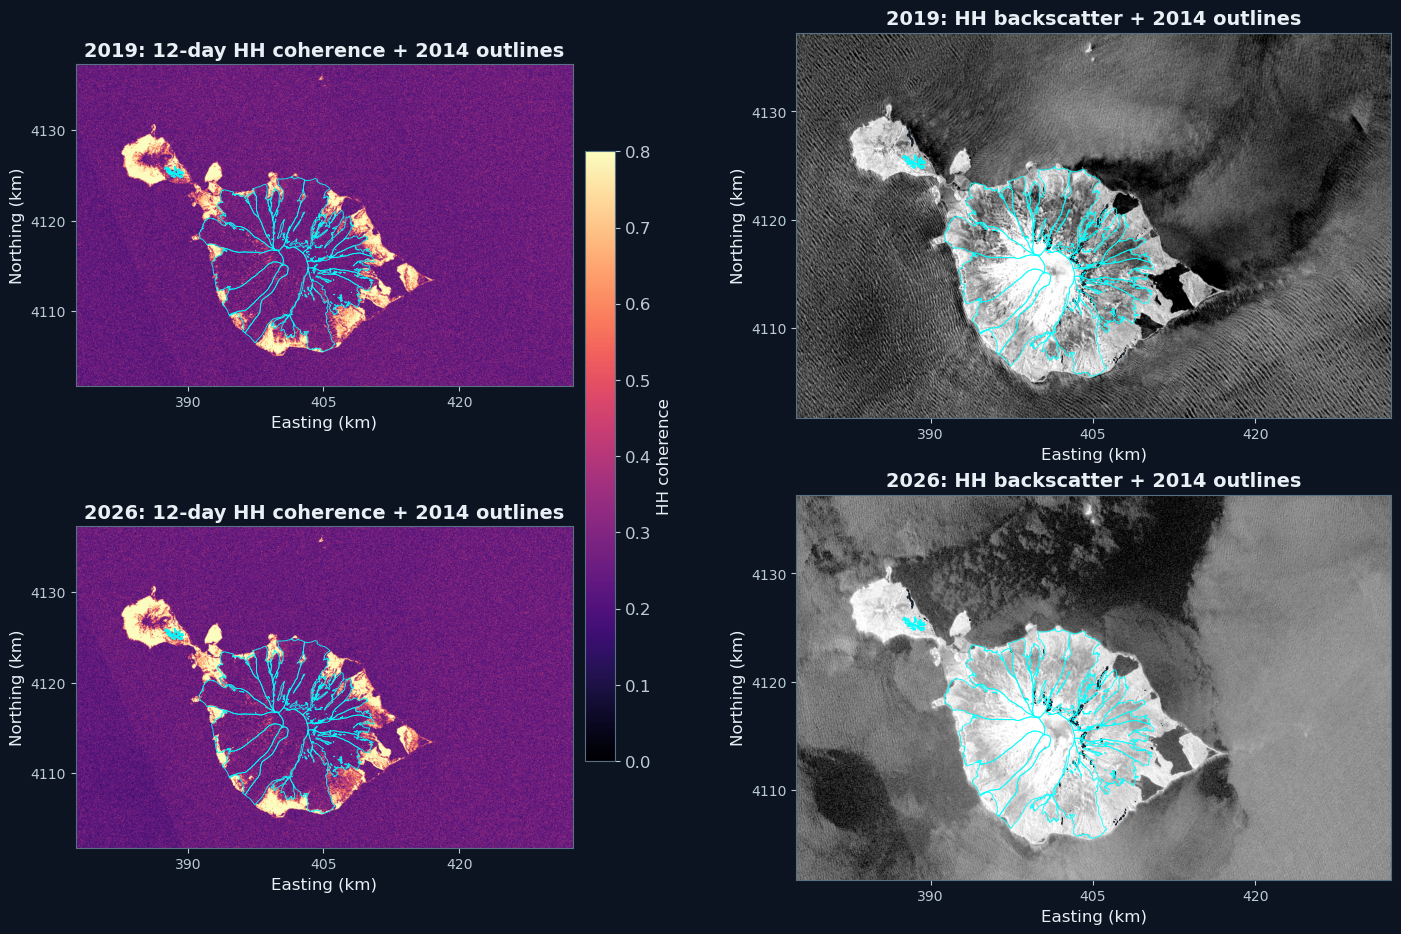

In [57]:
## Full-island SAR preview with 2014 glacier outlines ##

# Read the outlines once and put them in the mosaics' projected CRS.
with rasterio.open(radar_paths[2019]) as reference:
    map_crs = reference.crs

glaciers_2014 = gpd.read_file(glacier_path).to_crs(map_crs)

with plt.rc_context(book_plot_style):
    fig, axes = plt.subplots(2, 2, figsize = (17, 11))

    for row, year in enumerate((2019, 2026)):
        with rasterio.open(radar_paths[year]) as radar:
            # About one quarter of the original width and height is plenty
            # for a full-island inspection.
            preview_width = max(1, radar.width // 4)
            preview_height = max(1, radar.height // 4)

            preview_transform = radar.transform * radar.transform.scale(
                radar.width / preview_width,
                radar.height / preview_height)

            hh = radar.read(
                1,
                out_shape = (preview_height, preview_width),
                resampling = Resampling.average)

            data_mask = radar.read(
                3,
                out_shape = (preview_height, preview_width),
                resampling = Resampling.nearest) > 0.5

            extent = (
                radar.bounds.left,
                radar.bounds.right,
                radar.bounds.bottom,
                radar.bounds.top)

            # Warp the coherence image directly onto this small preview grid.
            with rasterio.open(coherence_paths[year]) as coherence_source:
                with WarpedVRT(
                    coherence_source,
                    crs = radar.crs,
                    transform = preview_transform,
                    width = preview_width,
                    height = preview_height,
                    src_nodata = 0,
                    nodata = 0,
                    resampling = Resampling.average) as coherence_vrt:

                    coherence = coherence_vrt.read(1, masked = True)

        valid_hh = data_mask & np.isfinite(hh) & (hh > -90)
        hh_limits = np.percentile(hh[valid_hh], [2, 98])

        coherence = np.ma.masked_where(~data_mask, coherence)
        hh_display = np.ma.masked_where(~valid_hh, hh)

        coherence_image = axes[row, 0].imshow(
            coherence,
            extent = extent,
            origin = "upper",
            cmap = "magma",
            vmin = 0,
            vmax = 0.8)

        axes[row, 1].imshow(
            hh_display,
            extent = extent,
            origin = "upper",
            cmap = "gray",
            vmin = hh_limits[0],
            vmax = hh_limits[1])

        for ax in axes[row]:
            glaciers_2014.boundary.plot(
                ax = ax,
                color = "cyan",
                linewidth = 0.65,
                alpha = 0.9)

            ax.set_xlabel("Easting (m)")
            ax.set_ylabel("Northing (m)")

        axes[row, 0].set_title(f"{year}: 12-day HH coherence + 2014 outlines")
        axes[row, 1].set_title(f"{year}: HH backscatter + 2014 outlines")

    fig.colorbar(
        coherence_image,
        ax = axes[:, 0],
        label = "HH coherence",
        shrink = 0.72,
        pad = 0.02)

    save_methodology_figure(fig, axes, "Inventory_methods_SAR_evidence")
    
    plt.show()

In [17]:
## Set segmentation parameters and load the reference grid ##

# Retain the parameter values used for the accepted outlines.
smooth_sigma_m = 30.0
ice_seed_max = 0.22
rock_seed_min = 0.45
seed_inset_m = 200.0
minimum_seed_area_m2 = 1000.0
minimum_polygon_area_m2 = 1000.0

required = [
    glacier_path, coast_path, lagoon_path,
    *radar_paths.values(), *coherence_paths.values()]

missing = [str(path) for path in required if not path.exists()]

if missing:
    raise FileNotFoundError(
        "Required inputs are missing: " + "; ".join(missing))

with rasterio.open(radar_paths[2019]) as reference:
    map_crs = reference.crs
    transform = reference.transform
    height, width = reference.height, reference.width
    x_res, y_res = reference.res
    bounds = reference.bounds
    grid = (map_crs, transform, height, width)

if map_crs is None or map_crs.to_epsg() != 32743:
    raise ValueError("Expected the existing EPSG:32743 metre-based SAR grid")

coast = gpd.read_file(coast_path).to_crs(map_crs)
glaciers = gpd.read_file(glacier_path).to_crs(map_crs)

In [18]:
## Prepare land and glacier-interior masks ##

def polygon_mask(frame):
    # Rasterise valid polygons on the existing SAR grid.
    geometries = frame.geometry.make_valid()
    geometries = geometries[
        geometries.notna() & ~geometries.is_empty]
    return rasterize(
        ((geometry, 1) for geometry in geometries),
        out_shape = (height, width), transform = transform,
        fill = 0, dtype = "uint8").astype(bool)

land = polygon_mask(coast)
old_ice = polygon_mask(glaciers)
# Erode the combined ice footprint, not each glacier's internal divide.
old_interior = ndi.distance_transform_edt(
    old_ice, sampling = (y_res, x_res)) >= seed_inset_m
pixel_area = x_res * y_res
minimum_seed_pixels = max(1, int(np.ceil(
    minimum_seed_area_m2 / pixel_area)))
minimum_polygon_pixels = max(1, int(np.ceil(
    minimum_polygon_area_m2 / pixel_area)))

def retain_components(mask, minimum_pixels):
    # Remove isolated patches smaller than the chosen mapping unit.
    components, _ = ndi.label(mask)
    sizes = np.bincount(components.ravel())
    keep = sizes >= minimum_pixels
    keep[0] = False
    return keep[components]


In [19]:
## Define the elevation zone held unchanged from 2014 ##

high_elevation_lock_m = 1000

# Locate the project DEM within the input directory.
dem_matches = sorted(input_dir.rglob("HI_dem2019.tif"))

if len(dem_matches) != 1:
    raise ValueError(
        "Expected one HI_dem2019.tif under Input_Data; "
        f"found {len(dem_matches)}. Set dem_path explicitly if needed.")

dem_path = dem_matches[0]

# Align the DEM with the existing SAR processing grid.
with rasterio.open(dem_path) as dem_source:
    with WarpedVRT(
        dem_source,
        crs = map_crs,
        transform = transform,
        width = width,
        height = height,
        resampling = Resampling.bilinear) as aligned_dem:

        lock_elevation = aligned_dem.read(
            1, masked = True).astype("float32").filled(np.nan)

high_elevation = (
    np.isfinite(lock_elevation)
    & (lock_elevation > high_elevation_lock_m))

print(f"2014 ice extent will be retained above {high_elevation_lock_m} m.")

2014 ice extent will be retained above 1000 m.


In [20]:
## Trace coherence boundaries with seeded watershed ##

def segment_coherence(coherence, valid, interior):
    # Return a candidate mask, seed map and smoothed coherence.
    # Normalised smoothing prevents NoData and the sea lowering land values.
    sigma = (smooth_sigma_m / y_res, smooth_sigma_m / x_res)
    weights = ndi.gaussian_filter(
        valid.astype("float32"), sigma = sigma)
    weighted = ndi.gaussian_filter(
        np.where(valid, coherence, 0).astype("float32"), sigma = sigma)
    smooth = np.divide(
        weighted, weights, out = np.zeros_like(weighted),
        where = weights > 1e-6)

    # Thresholds select seed interiors. They do not set the final border.
    ice_seeds = retain_components(
        valid & interior & (smooth <= ice_seed_max), minimum_seed_pixels)
    rock_seeds = retain_components(
        valid & (smooth >= rock_seed_min), minimum_seed_pixels)
        # Treat mapped high-elevation ice as ice seeds, regardless of coherence.
    ice_seeds |= valid & high_elevation & old_ice
    rock_seeds &= ~(high_elevation & old_ice)
    if not ice_seeds.any() or not rock_seeds.any():
        raise ValueError(
            "Both ice and stable-terrain seeds are required. "
            "These starting seed thresholds do not fit this scene.")

    markers = np.zeros(coherence.shape, dtype = "int32")
    markers[ice_seeds] = 1
    markers[rock_seeds] = 2

    # Do not call an isolated unseeded area ice by elimination.
    components, count = ndi.label(valid)
    has_ice = np.zeros(count + 1, dtype = bool)
    has_rock = np.zeros(count + 1, dtype = bool)
    has_ice[np.unique(components[ice_seeds])] = True
    has_rock[np.unique(components[rock_seeds])] = True
    usable = has_ice & has_rock
    usable[0] = False
    domain = valid & usable[components]
    markers[~domain] = 0

    # Bright gradient ridges are the barriers between growing regions.
    gradient = sobel(smooth, mask = valid).astype("float32")
    regions = watershed(
        gradient, markers = markers, mask = domain, connectivity = 1)
    # Restrict candidate ice to the combined 2014 footprint.
    ice = retain_components(
        (regions == 1) & old_ice, minimum_polygon_pixels)
    
    # Restore the 2014 footprint above the cutoff, including radar gaps.
    # Existing rock holes and the coastline/lagoon exclusions remain.
    ice[high_elevation] = (old_ice & land)[high_elevation]

    # 0 = outside coastline; 1 = candidate ice; 2 = candidate stable terrain;
    # 3 = unresolved land (also includes missing/shadowed observations).
    classes = np.zeros(coherence.shape, dtype = "uint8")
    classes[land] = 3
    classes[regions == 2] = 2
    classes[ice] = 1
    return classes, markers.astype("uint8"), smooth


In [21]:
## Exclude the updated 2014 lagoons ##

lagoons = gpd.read_file(lagoon_path).to_crs(map_crs)
lagoon_mask = polygon_mask(lagoons)

# Rebuild the processing mask from the coastline, excluding mapped water.
coast_land = polygon_mask(coast)
land = coast_land & ~lagoon_mask

# Save this version separately from the original candidate outlines.
output_dir.mkdir(parents = True, exist_ok = True)

excluded_area = np.count_nonzero(
    coast_land & lagoon_mask) * pixel_area / 1_000_000

print(f"Mapped lagoon area excluded: {excluded_area:.3f} km²")

Mapped lagoon area excluded: 16.808 km²


2019: reading existing rasters and tracing boundaries...


C:\Users\harry\AppData\Local\Temp\ipykernel_9908\2082438363.py:34: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  data_valid = radar.read(3) > 0.5
C:\Users\harry\AppData\Local\Temp\ipykernel_9908\2082438363.py:35: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  shadow = radar.read(2) > 0.5
c:\Users\harry\anaconda3\envs\KGG375_AT3\Lib\site-packages\rasterio\features.py:129: RuntimeWarning: DeprecationWarning: 'Memory' driver is deprecated since GDAL 3.11. Use 'MEM' onwards. Further messages of this type will be suppressed.
  yield from _shapes(source, mask, connectivity, transform)


Saved c:\Users\harry\OneDrive\Desktop\UNI\UTAS\2026\KGG375_Geospatial_Data_Analytics\AT3\AT3_Group2_2026\Output_Data\processed\coherence_watershed_v5_1000m_lock\Heard_ice_candidate_2019.shp | 24 polygons | 6.5% of mapped land unresolved
2026: reading existing rasters and tracing boundaries...


C:\Users\harry\AppData\Local\Temp\ipykernel_9908\2082438363.py:34: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  data_valid = radar.read(3) > 0.5
C:\Users\harry\AppData\Local\Temp\ipykernel_9908\2082438363.py:35: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  shadow = radar.read(2) > 0.5


Saved c:\Users\harry\OneDrive\Desktop\UNI\UTAS\2026\KGG375_Geospatial_Data_Analytics\AT3\AT3_Group2_2026\Output_Data\processed\coherence_watershed_v5_1000m_lock\Heard_ice_candidate_2026.shp | 19 polygons | 6.2% of mapped land unresolved


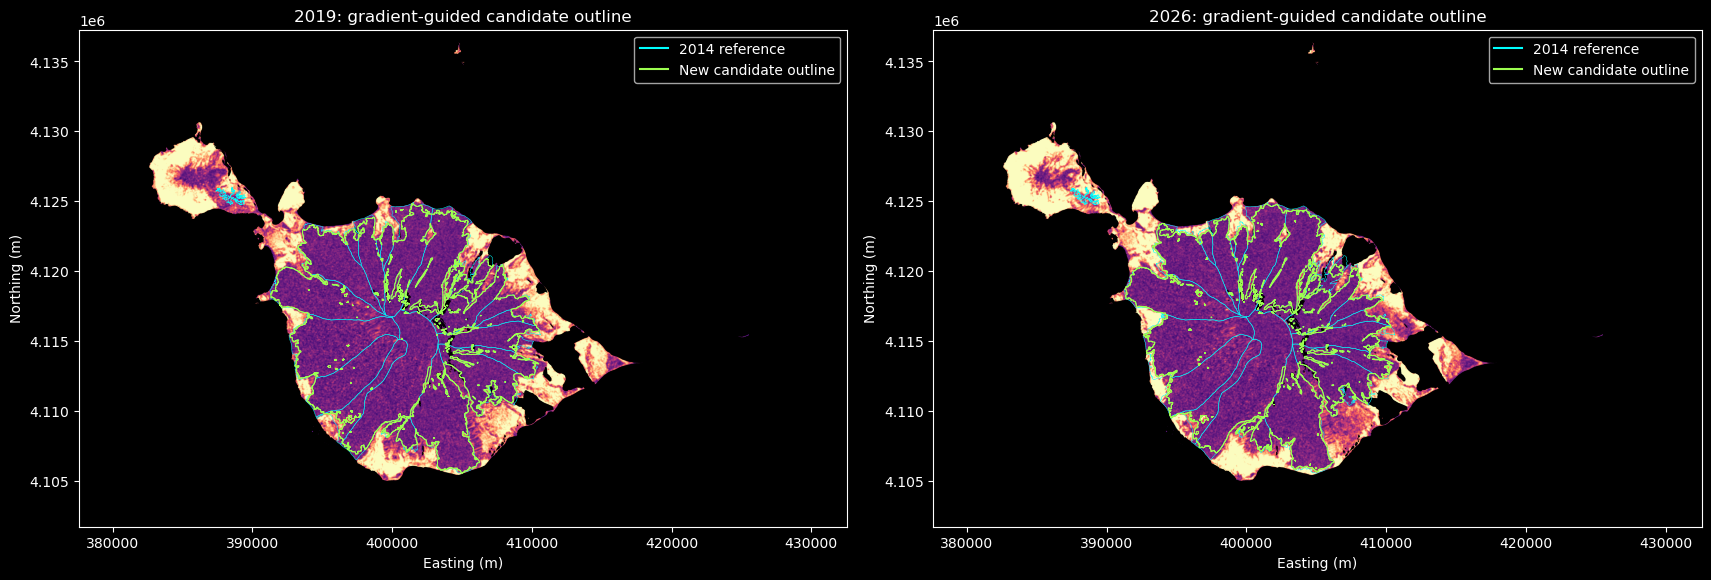

Done. Open both shapefiles and the assessment rasters in QGIS.


In [22]:
## Generate and export 2019 and 2026 candidate outlines ##

settings = {
    "method": "Gaussian smoothing, Sobel gradient, marker watershed",
    "status": "candidate; imagery review required",
    "smooth_sigma_m": smooth_sigma_m,
    "ice_seed_max": ice_seed_max,
    "rock_seed_min": rock_seed_min,
    "seed_inset_m": seed_inset_m,
    "minimum_seed_area_m2": minimum_seed_area_m2,
    "minimum_polygon_area_m2": minimum_polygon_area_m2,
    "crs": str(map_crs),
    "extent_constraint": "within_2014_footprint",
    "high_elevation_lock_m": high_elevation_lock_m,
    "high_elevation_reference": "2014 ice footprint",
    "dem_path": str(dem_path),
    "radar_paths": {str(k): str(v) for k, v in radar_paths.items()},
    "coherence_paths": {str(k): str(v) for k, v in coherence_paths.items()},
    "outline_path": str(glacier_path), "coastline_path": str(coast_path), "lagoon_path": str(lagoon_path)}
(output_dir / "settings.json").write_text(
    json.dumps(settings, indent = 2), encoding = "utf-8")

extent = (bounds.left, bounds.right, bounds.bottom, bounds.top)
with plt.style.context("dark_background"):
    fig, axes = plt.subplots(
        1, 2, figsize = (17, 8), layout = "constrained")

    for ax, year in zip(axes, radar_paths):
        print(f"{year}: reading existing rasters and tracing boundaries...",
              flush = True)
        with rasterio.open(radar_paths[year]) as radar:
            if (radar.crs, radar.transform, radar.height, radar.width) != grid:
                raise ValueError(f"{year}: SAR grids differ")
            data_valid = radar.read(3) > 0.5
            shadow = radar.read(2) > 0.5
        with rasterio.open(coherence_paths[year]) as source:
            with WarpedVRT(
                source, crs = map_crs, transform = transform,
                width = width, height = height,
                resampling = Resampling.bilinear) as aligned:
                coherence = aligned.read(
                    1, masked = True).astype("float32").filled(np.nan)

        valid = (land & data_valid & ~shadow & np.isfinite(coherence)
                 & (coherence >= 0) & (coherence <= 1))
        classes, markers, smooth = segment_coherence(
            coherence, valid, old_interior)

        raster_path = output_dir / f"Heard_watershed_{year}.tif"
        with rasterio.open(
            raster_path, "w", driver = "GTiff", width = width,
            height = height, count = 2, dtype = "uint8", crs = map_crs,
            transform = transform, compress = "deflate", tiled = True) as dst:
            dst.write(classes, 1)
            dst.write(markers, 2)
            dst.set_band_description(
                1, "0 outside coast or mapped lagoon; 1 candidate ice; 2 stable terrain; 3 unresolved")
            dst.set_band_description(
                2, "Watershed seeds: 0 none; 1 ice; 2 stable terrain")
            dst.update_tags(status = "DRAFT", method = settings["method"])

        # Polygonise regions, preserving holes and the original grid's CRS.
        records = [
            {"year": year, "status": "candidate",
             "geometry": shapely_shape(geometry)}
            for geometry, value in shapes(
                classes, mask = classes == 1, transform = transform,
                connectivity = 4) if value == 1]
        if not records:
            raise ValueError(f"{year}: no candidate ice polygons were produced")
        outlines = gpd.GeoDataFrame(records, crs = map_crs)
                # Clip edge pixels precisely to the original vector boundary.
        footprint_2014 = glaciers.geometry.make_valid().union_all()
        outlines = gpd.clip(
            outlines, footprint_2014, keep_geom_type = True)
        shp_path = output_dir / f"Heard_ice_candidate_{year}.shp"
        outlines.to_file(shp_path, driver = "ESRI Shapefile", index = False)

        ax.imshow(
            np.ma.masked_where(~valid, smooth), extent = extent,
            origin = "upper", cmap = "magma", vmin = 0, vmax = 0.8)
        glaciers.boundary.plot(ax = ax, color = "cyan", linewidth = 0.35)
        outlines.boundary.plot(ax = ax, color = "#9dff50", linewidth = 0.75)
        ax.plot([], [], color = "cyan", label = "2014 reference")
        ax.plot([], [], color = "#9dff50", label = "New candidate outline")
        ax.set(xlim = (bounds.left, bounds.right),
               ylim = (bounds.bottom, bounds.top),
               title = f"{year}: gradient-guided candidate outline",
               xlabel = "Easting (m)", ylabel = "Northing (m)")
        ax.legend(loc = "upper right")
        unresolved = np.count_nonzero(classes == 3) / np.count_nonzero(land)
        print(f"Saved {shp_path} | {len(outlines)} polygons | "
              f"{unresolved:.1%} of mapped land unresolved", flush = True)
        del coherence, classes, markers, smooth, valid

    plt.show()

print("Done. Open both shapefiles and the assessment rasters in QGIS.")


In [23]:
## Lock the 2019 reference and constrain the 2026 candidate ##

source_dir = output_dir

locked_dir.mkdir(parents = True, exist_ok = True)

reference_path = locked_dir / "Heard_ice_2019_reference.gpkg"
candidate_path = locked_dir / "Heard_ice_2026_within_2019.gpkg"

# Reuse the saved reference so reruns cannot silently replace it.
if reference_path.exists():
    reference_2019 = gpd.read_file(reference_path, layer = "ice_2019")
    print("Reusing the locked 2019 reference.")

else:
    reference_2019 = gpd.read_file(
        source_dir / "Heard_ice_candidate_2019.shp")

    reference_2019["geometry"] = (
        reference_2019.geometry.make_valid())

    reference_2019 = reference_2019[["geometry"]].dissolve()
    reference_2019["year"] = 2019
    reference_2019["use_scope"] = "Brown and Stephenson"
    reference_2019["status"] = "Accepted for study glaciers"

    reference_2019.to_file(
        reference_path, layer = "ice_2019",
        driver = "GPKG", index = False)

    print("Saved the locked 2019 reference.")

# Intersect the existing 2026 candidate with the complete 2019 geometry.
candidate_2026 = gpd.read_file(
    source_dir / "Heard_ice_candidate_2026.shp")

candidate_2026 = candidate_2026.to_crs(reference_2019.crs)
candidate_2026["geometry"] = candidate_2026.geometry.make_valid()

constrained_2026 = gpd.clip(
    candidate_2026, reference_2019, keep_geom_type = True)

constrained_2026["constraint"] = "Within 2019 ice footprint"
constrained_2026["status"] = "Candidate"

constrained_2026.to_file(
    candidate_path, layer = "ice_2026",
    driver = "GPKG", index = False)

print(f"2019 reference: {reference_path}")
print(f"2026 candidate: {candidate_path}")

Reusing the locked 2019 reference.
2019 reference: c:\Users\harry\OneDrive\Desktop\UNI\UTAS\2026\KGG375_Geospatial_Data_Analytics\AT3\AT3_Group2_2026\Output_Data\processed\coherence_watershed_v6_1000m_lock\Heard_ice_2019_reference.gpkg
2026 candidate: c:\Users\harry\OneDrive\Desktop\UNI\UTAS\2026\KGG375_Geospatial_Data_Analytics\AT3\AT3_Group2_2026\Output_Data\processed\coherence_watershed_v6_1000m_lock\Heard_ice_2026_within_2019.gpkg


In [25]:
# Load the frozen outlines from the final output directory.
final_2019 = gpd.read_file(
    final_dir / "Heard_ice_2019_final.gpkg", layer = "ice_2019")

final_2026 = gpd.read_file(
    final_dir / "Heard_ice_2026_final.gpkg", layer = "ice_2026")

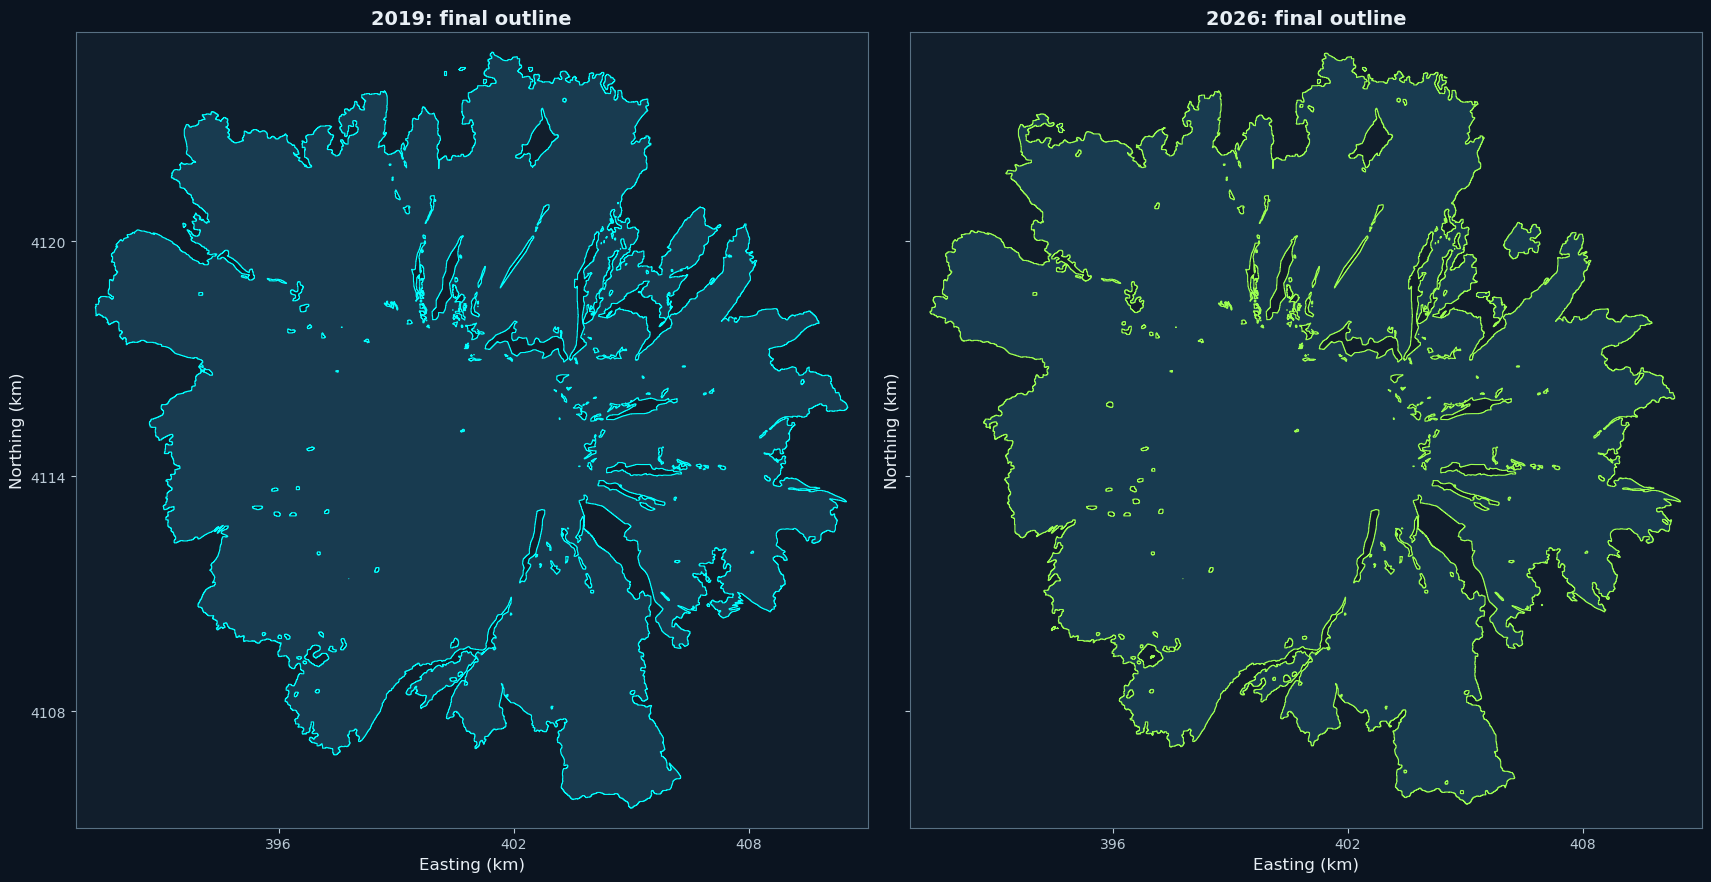

In [58]:
## Compare the final saved outlines ##

# Compare both years at the same scale, retaining internal holes.
comparison_2026 = final_2026[["geometry"]].dissolve()
plot_left, plot_bottom, plot_right, plot_top = final_2019.total_bounds
plot_margin = 500

with plt.rc_context(book_plot_style):
    comparison_fig, comparison_axes = plt.subplots(
        1, 2, figsize = (17, 9),
        sharex = True, sharey = True,
        layout = "constrained")

    for ax, layer, title, colour in zip(
        comparison_axes,
        (final_2019, comparison_2026),
        ("2019: final outline", "2026: final outline"),
        ("cyan", "#9DFF50")):

        layer.plot(
            ax = ax,
            facecolor = "#183B50",
            edgecolor = colour,
            linewidth = 0.8)

        ax.set(
            title = title,
            xlabel = "Easting (m)",
            ylabel = "Northing (m)",
            xlim = (
                plot_left - plot_margin,
                plot_right + plot_margin),
            ylim = (
                plot_bottom - plot_margin,
                plot_top + plot_margin))

        ax.set_aspect("equal")
        
    save_methodology_figure(comparison_fig, comparison_axes,"Inventory_methods_final_extents")

    plt.show()

In [27]:
## Finalise and save the accepted 2019 and 2026 outlines ##

source_dir = locked_dir

source_files = {
    2019: "Heard_ice_2019_reference.gpkg",
    2026: "Heard_ice_2026_within_2019.gpkg"}

if final_dir.exists():
    # Reuse the frozen outputs when the notebook is run again.
    print("Final outlines already exist. Reusing the saved copies.")

else:
    # Read the accepted outlines, including the final 2026 constraint.
    accepted_outlines = {
        year: gpd.read_file(source_dir / filename, layer = f"ice_{year}")
        for year, filename in source_files.items()}

    # Check that both inputs contain valid polygons on the expected grid CRS.
    for year, frame in accepted_outlines.items():
        if frame.crs is None or frame.crs.to_epsg() != 32743:
            raise ValueError(f"{year}: expected EPSG:32743.")

        if (
            frame.empty
            or frame.geometry.isna().any()
            or frame.geometry.is_empty.any()
            or not frame.geometry.is_valid.all()
            or not frame.geom_type.isin(["Polygon", "MultiPolygon"]).all()):
            raise ValueError(f"{year}: missing or invalid outline geometry.")

    # Confirm that 2026 remains within 2019, allowing numerical slivers only.
    footprint_2019 = accepted_outlines[2019].geometry.union_all()
    footprint_2026 = accepted_outlines[2026].geometry.union_all()
    outside_area = footprint_2026.difference(footprint_2019).area

    if outside_area > 1.0:
        raise ValueError(
            f"2026 extends outside 2019 by {outside_area:.2f} m². "
            "Rerun the cell that constrains 2026 to the 2019 reference.")

    # Record the assumptions alongside the final vector files.
    metadata = {
        "saved_utc": datetime.now(timezone.utc).isoformat(),
        "comparison_years": [1947, 1988, 2014, 2019, 2026],
        "accepted_study_glaciers": ["Brown", "Stephenson"],
        "source_files": {
            str(year): str(source_dir / filename)
            for year, filename in source_files.items()},
        "method": "HH coherence gradient with marker-controlled watershed",
        "extent_constraints": {
            "2019": "Within the 2014 ice footprint",
            "2026": "Within the accepted 2019 ice footprint"},
        "high_elevation_rule": (
            "Above 1000 m, retain the 2014 ice footprint in both years, "
            "subject to coastline and lagoon exclusions."),
        "lagoon_exclusion": "UpdatedHI_Lagoons2014.shp",
        "interpretation": (
            "No advance and no change above 1000 m are imposed assumptions. "
            "Acceptance concerns Brown and Stephenson; other glaciers retain "
            "known mapping issues and have not been accepted for analysis.")}

    # Preserve the saved segmentation settings where available.
    settings_path = output_dir / "settings.json"

    if settings_path.exists():
        metadata["segmentation_settings"] = json.loads(
            settings_path.read_text(encoding = "utf-8"))

    # Complete both exports before creating the final output folder.
    final_dir.parent.mkdir(parents = True, exist_ok = True)

    with TemporaryDirectory(dir = final_dir.parent) as temporary_dir:
        staging_dir = Path(temporary_dir) / final_dir.name
        staging_dir.mkdir()

        for year, frame in accepted_outlines.items():
            # Keep the geometry unchanged and replace draft attributes.
            final_outline = frame[["geometry"]].copy()
            final_outline["year"] = year
            final_outline["status"] = "accepted"
            final_outline["scope"] = "Brown and Stephenson"
            final_outline["lock_m"] = 1000

            final_outline.to_file(
                staging_dir / f"Heard_ice_{year}_final.gpkg",
                layer = f"ice_{year}", driver = "GPKG", index = False)

            final_outline.to_file(
                staging_dir / f"Heard_ice_{year}_final.shp",
                driver = "ESRI Shapefile", index = False)

        (staging_dir / "outline_metadata.json").write_text(
            json.dumps(metadata, indent = 2), encoding = "utf-8")

        staging_dir.rename(final_dir)

    print("Both years finalised and saved.")

# Load the frozen GeoPackages for subsequent analysis.
final_2019 = gpd.read_file(
    final_dir / "Heard_ice_2019_final.gpkg", layer = "ice_2019")

final_2026 = gpd.read_file(
    final_dir / "Heard_ice_2026_final.gpkg", layer = "ice_2026")

print(f"Final outlines: {final_dir.resolve()}")

Final outlines already exist. Reusing the saved copies.
Final outlines: C:\Users\harry\OneDrive\Desktop\UNI\UTAS\2026\KGG375_Geospatial_Data_Analytics\AT3\AT3_Group2_2026\Output_Data\processed\glacier_outlines_final
